In [2]:
import numpy as np
import matplotlib.pylab as plt

dict_keys([20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000, 500000, 1000000, 2000000, 5000000])


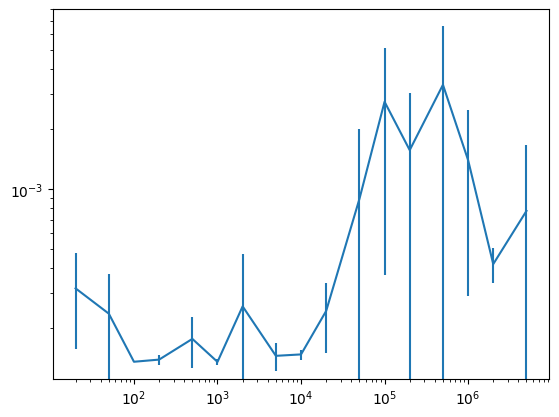

In [ ]:
def parser(filename = "./data/performanceData/exact_Halfing.txt"):
    file = open(filename)
    line = file.readline()
    if (line != "SetSize, VertexSet Time [s], Dense Time [s], Sparse Time [s]\n"):
        print("Error: Wrong format for parser")
        return
    line = file.readline()
    vertexSet = {}
    dense = {}
    sparse = {}
    while line != "":
        chunks = line.split(",")
        size = (int(chunks[0]))
        if (size in vertexSet.keys()):
            vertexSet[size].append(float(chunks[1]))
            dense[size].append(float(chunks[2]))
            sparse[size].append(float(chunks[3]))
        else:
            vertexSet[size] =[float(chunks[1])]
            dense[size] = [float(chunks[2])]
            sparse[size] =[float(chunks[3])]
        line = file.readline()
    return vertexSet, dense, sparse

def getMeanAndError(dict):
    sizes = []
    means = []
    errors = []
    for size in dict.keys():
        sizes.append(size)
        array = np.array(dict[size])
        means.append(np.mean(array))
        if array.size > 0:
            errors.append(np.std(array))
        else:
            errors.append(0)
    return sizes, means, errors

vertexSet, dense, sparse = parser()
print(dense.keys())
sizes, vals, errors = getMeanAndError(dense)

fig = plt.figure
ax = plt.axes()
ax.errorbar(sizes, vals, yerr=errors, capsize=4)
ax.set_xscale("log")
ax.set_yscale("log")
